# kin_07 — Value encoding in tongue kinematics

**Do behavioural-model latents — action value and reward-prediction error — show up in
*how the tongue moves*?**

The dynamic-foraging task is fit, upstream, with a family of RL agents; the fits expose
per-trial latents (`q_value`, `choice_kernel`, `choice_prob`, `rpe`). The `kin_*` series
has never used them: `kin_01`–`kin_06` describe tongue movements in their own terms, and
`eph_06` compares RT encoding to a behavioural model but on the **ephys** side. This
notebook asks the kinematics-side version of that question.

The scientific target is deliberately narrow. Value is known to modulate *whether* and
*when* an animal responds; the question here is whether it also modulates the **motor
detail** of the response — how far the tongue goes, how fast, in what direction — once
the decision to lick has been made.

**Pipeline:**
1. Load the pooled `all_tongue_movements` parquet
2. Fetch MLE model fits per session, attach latents to trials, derive `q_diff`, `q_sum`,
   `q_diff_c`, `chosen_prob`, and validate the L/R row convention
3. Trajectories and endpoints coloured by value, one example session
4. The four kinematic × value pairs the source notebooks pin
5. A systematic screen: every kinematic × every model latent, four ways
6. Previous-trial RPE — does last trial's outcome change *this* trial's movement?

**Ported from** `tongue_kinematics.ipynb` cells 111–138 and
`tongue_kinematics_cueresponse.ipynb` cells 17–28, which carry two partly-overlapping
single-session copies of this analysis. Three things are deliberately **not** inherited
from them — see §3.6, §6 and the notes throughout:
pseudo-replication (latents merged onto movement rows), no multiple-comparison control,
and over-reading of correlated-feature importances.

**Local vs Code Ocean**
- **Code Ocean only**, except §6.1 (the kinematic covariance structure), which runs on the
  pooled parquet alone.
- The model-fit fetch itself is *not* Code Ocean-bound — it queries the analysis database
  over the network and works anywhere with credentials. What is Code Ocean-only is the
  per-session `nwb_df_trials.parquet` (for `animal_response`, which indexes the latents
  onto trials) and `intermediate_data/kps_raw_jaw.parquet` / `tongue_kins.parquet` for
  §4–§5. Sections gate on file availability, not on the environment flag, so they light
  up automatically if those tables ever land locally.

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold, cross_val_score

from statsmodels.stats.multitest import multipletests

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()


def fmt_p(pvalue, floor=1e-300):
    """Format a p-value, reporting underflow as a bound instead of "0".

    Parameters
    ----------
    pvalue : float
        p-value to format.
    floor : float
        Smallest value printed literally; anything below is shown as "< floor".

    Returns
    -------
    str
        Formatted p-value.
    """
    if not np.isfinite(pvalue):
        return "= nan"
    return "< {:.0e}".format(floor) if pvalue < floor else "= {:.3g}".format(pvalue)

In [2]:
if Path("/root/capsule").exists():
    ENV       = "codeocean"
    SCRATCH   = Path("/root/capsule/scratch")
    FOR_LOCAL = SCRATCH / "for_local"
else:
    ENV       = "local"
    FOR_LOCAL = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local")
    SCRATCH   = FOR_LOCAL.parent

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "kin_07_value_encoding"
SAVE_FIG = False

# Per-session intermediate data (Code Ocean only) — same asset kin_00/kin_05/kin_06 use.
SESSION_DIR = SCRATCH / "session_analysis_mlk"

# The agent both source notebooks fit against. Pinned here so the whole notebook refers
# to one model; every latent below is this agent's, not a model-averaged quantity.
AGENT_ALIAS = "QLearning_L2F1_CKfull_softmax"

# Sessions with fewer trials than this are dropped from the session-level statistics —
# a per-session Spearman rho on a handful of trials is noise, and it would enter the
# across-session test with the same weight as a full session.
MIN_TRIALS_PER_SESSION = 50

# Example session for the single-session figures — the one cueresponse itself used.
EXAMPLE_SESSION = "behavior_716325_2024-05-31_10-31-14"

EPS = 1e-10  # floor for chosen_prob before taking a log

print("ENV={}".format(ENV))

ENV=local


## 2. Load data

In [3]:
if ENV == "codeocean":
    movements_path = SCRATCH / "all_tongue_movements_04022026" / "all_tongue_movements_04022026.parquet"
else:
    movements_path = FOR_LOCAL / "all_tongue_movements_04022026.parquet"

all_tongue_movements = pd.read_parquet(movements_path)
print("Shape:", all_tongue_movements.shape)
print("Sessions:", all_tongue_movements["session"].nunique())


def coerce_bool(series):
    """Coerce an object-dtype True/False/None column to real booleans.

    Plain ``astype(bool)`` on an object column turns any non-empty string
    (including the string "False") into True. This instead treats only
    True/1/"True" as true and everything else, including None, as false.

    Parameters
    ----------
    series : pandas.Series
        Object-dtype column holding True/False/None (or their 1/0/string
        equivalents).

    Returns
    -------
    pandas.Series
        Boolean-dtype series.
    """
    return series.isin([True, 1, "True"])


df = all_tongue_movements.copy()
df["cue_response"] = coerce_bool(df["cue_response"])
SESSIONS = sorted(df["session"].unique())

print("\nCue-response movements:", int(df["cue_response"].sum()))
# One cue-response movement per trial is what makes the trial-level aggregation in
# 3.6 a relabelling rather than a reduction — check it rather than assume it.
per_trial = df.loc[df["cue_response"]].groupby(["session", "trial"]).size()
print("Trials with a cue-response movement:", len(per_trial))
print("Trials with more than one:", int((per_trial > 1).sum()))

Shape: (246359, 49)
Sessions: 44

Cue-response movements: 16029
Trials with a cue-response movement: 14138
Trials with more than one: 9


## 3. Attaching the behavioural-model latents

### 3.1 Where the latents come from

`get_mle_model_fitting` queries the AIND analysis database for MLE fits of the
dynamic-foraging behaviour and pulls the per-trial latent arrays from S3. For each
session and agent it returns, among other things:

| array | shape | meaning |
|---|---|---|
| `q_value` | `(2, N+1)` | action value for [left, right], with a trailing post-session update |
| `choice_kernel` | `(2, N+1)` | choice-perseveration kernel, same trailing entry |
| `choice_prob` | `(2, N)` | model probability of choosing [left, right] |
| `rpe` | `(N,)` | reward-prediction error on each trial |

`N` is the fit's `n_trials`. `q_value` and `choice_kernel` are trimmed to `[:, :N]`
(dropping the post-session update) before use, as both source copies do.

**Dependency status, checked this session.** `get_mle_model_fitting` still resolves, but
`aind_analysis_arch_result_access.han_pipeline.get_mle_model_fitting` — the import path
both source notebooks use — is now a **deprecated shim** that forwards to
`aind_analysis_arch_result_access.df_mle_model_fitting.get_mle_model_fitting` and logs a
warning. The import below prefers the new path and falls back to the shim, so the
notebook survives the shim's eventual removal. The `environment/Dockerfile` installs the
package unpinned (`aind_analysis_arch_result_access --upgrade`), so Code Ocean tracks
whatever is current — which is the argument for not importing through the shim.

**Coverage, measured over all 44 sessions:** 40 of 44 have a
`QLearning_L2F1_CKfull_softmax` fit; the four sessions of subject **751004**
(2024-12-20 … 2024-12-23) have **no MLE records at all** and drop out. The whole sweep
takes ~48 s, which is what settles the pooling question below.

### 3.2 Pooling — and why

Both source copies run on **one** session. This notebook **pools across sessions**, for
two reasons:

1. **Cost is not the constraint.** Fetching fits for all 44 sessions takes ~48 s end to
   end (measured, not estimated): 40 resolve, 4 have no records. There is no rate limit
   to work around at this scale.
2. **It is what makes the statistics possible.** The question "does value modulate
   kinematics" is a population claim. With one session there is no sampling unit above
   the trial, which is precisely the hole §3.6 is about. Pooling gives 40 sessions and
   lets **session** be the unit of inference.

The sampling unit is stated explicitly at each analysis below, because it is not the same
everywhere: §5 and the Spearman/RidgeCV panels of §6 use **session**; the mutual-information
and random-forest panels of §6 are **descriptive over trials**, with a within-session
shuffled null as their only reference. See §6 for why.

In [4]:
# Prefer the migrated implementation; fall back to the deprecated han_pipeline shim.
try:
    from aind_analysis_arch_result_access.df_mle_model_fitting import get_mle_model_fitting
    _MLE_IMPORT = "df_mle_model_fitting (current)"
except ImportError:                                     # pragma: no cover - older package
    from aind_analysis_arch_result_access.han_pipeline import get_mle_model_fitting
    _MLE_IMPORT = "han_pipeline (deprecated shim)"
print("get_mle_model_fitting imported from:", _MLE_IMPORT)


def parse_session_id(session):
    """Split a session folder name into subject id and session date.

    Parameters
    ----------
    session : str
        Session name like ``behavior_716325_2024-05-31_10-31-14``.

    Returns
    -------
    tuple of (str, str)
        ``(subject_id, session_date)``.

    Raises
    ------
    ValueError
        If the name does not match the expected pattern.
    """
    match = re.match(r"behavior_(\d+)_(\d{4}-\d{2}-\d{2})", session)
    if match is None:
        raise ValueError("Unrecognised session name: {}".format(session))
    return match.group(1), match.group(2)


def fetch_model_latents(session, agent_alias=AGENT_ALIAS):
    """Fetch one session's MLE fit for a single agent and return its latents.

    Parameters
    ----------
    session : str
        Session folder name.
    agent_alias : str
        Model agent to select from the returned fit table.

    Returns
    -------
    tuple of (pandas.DataFrame, pandas.Series) or (None, None)
        ``(model_latents, fit_row)`` where ``model_latents`` is the
        ``pd.json_normalize`` of the fit's ``latent_variables`` (one row, columns
        ``q_value`` / ``choice_kernel`` / ``choice_prob`` / ``rpe``) and
        ``fit_row`` is the full record (carrying ``n_trials``,
        ``prediction_accuracy``, ``params``). ``(None, None)`` when the session
        has no records, or none for this agent.
    """
    subject_id, session_date = parse_session_id(session)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        models_df = get_mle_model_fitting(subject_id=subject_id, session_date=session_date)

    if models_df is None or len(models_df) == 0:
        return None, None
    fit = models_df[models_df["agent_alias"] == agent_alias]
    if len(fit) == 0:
        return None, None

    fit_row = fit.iloc[0]
    if fit_row.get("latent_variables") is None:
        return None, fit_row
    return pd.json_normalize(fit["latent_variables"]), fit_row

get_mle_model_fitting imported from: df_mle_model_fitting (current)


In [5]:
def attach_model_latents_to_trials(df_trials, model_latents):
    """Attach model latent variables to a session's trial table.

    Ported from ``tongue_kinematics`` cell 115 / ``tongue_kinematics_cueresponse``
    cell 13. The two source copies are *not* identical — see the note below — and
    both had their alignment assertions commented out. Those are restored here,
    because a silent length mismatch would shift every latent by an unknown number
    of trials without raising.

    The latents are indexed by the trials the model was fit on. Which trials those
    are is not documented by the upstream API, so rather than assuming, this checks
    the fit length against both candidates — the responded trials
    (``animal_response`` in {0, 1}, which is what both source copies assume) and all
    trials — and records which one matched in a ``latent_index_mode`` column.

    Parameters
    ----------
    df_trials : pandas.DataFrame
        Trial-level table (``nwb_df_trials.parquet``), indexed by trial number,
        with an ``animal_response`` column (0 = left, 1 = right, other = ignored).
    model_latents : pandas.DataFrame
        One-row frame from ``pd.json_normalize(fit["latent_variables"])`` with
        ``q_value``, ``choice_kernel``, ``choice_prob`` and ``rpe`` columns.

    Returns
    -------
    pandas.DataFrame
        Copy of ``df_trials`` with ``L_prob``, ``R_prob``, ``L_value``,
        ``R_value``, ``L_kernel``, ``R_kernel``, ``rpe`` and a constant
        ``latent_index_mode`` ("responded" or "all") column added.

    Raises
    ------
    ValueError
        If the latent arrays disagree with each other in length, or if their
        length matches neither the responded-trial count nor the trial count.

    Notes
    -----
    Row order within each ``(2, N)`` array is taken to be ``[left, right]``,
    following both source copies. §3.5 validates that convention against the
    fit's own reported ``prediction_accuracy`` rather than trusting it.
    """
    df_trials = df_trials.copy()
    responded_idx = df_trials.index[df_trials["animal_response"].isin([0, 1])]

    q_values = np.asarray(model_latents["q_value"].iloc[0], dtype=float)
    ck_values = np.asarray(model_latents["choice_kernel"].iloc[0], dtype=float)
    cp_values = np.asarray(model_latents["choice_prob"].iloc[0], dtype=float)
    rpe_values = np.asarray(model_latents["rpe"].iloc[0], dtype=float)

    # q_value and choice_kernel carry one extra column: the post-session update
    # after the last trial's outcome. Trim it, as both source copies do.
    n_fit = cp_values.shape[1]
    q_values = q_values[:, :n_fit]
    ck_values = ck_values[:, :n_fit]
    if len(rpe_values) != n_fit or q_values.shape[1] != n_fit or ck_values.shape[1] != n_fit:
        raise ValueError(
            "Latent arrays disagree: choice_prob={}, q_value={}, choice_kernel={}, "
            "rpe={}".format(n_fit, q_values.shape[1], ck_values.shape[1], len(rpe_values)))

    if len(responded_idx) == n_fit:
        target_idx, mode = responded_idx, "responded"
    elif len(df_trials) == n_fit:
        target_idx, mode = df_trials.index, "all"
    else:
        raise ValueError(
            "Latent length {} matches neither the responded trials ({}) nor all "
            "trials ({}).".format(n_fit, len(responded_idx), len(df_trials)))

    for col in ["L_prob", "R_prob", "L_value", "R_value", "L_kernel", "R_kernel", "rpe"]:
        df_trials[col] = np.nan

    df_trials.loc[target_idx, "L_prob"] = cp_values[0]
    df_trials.loc[target_idx, "R_prob"] = cp_values[1]
    df_trials.loc[target_idx, "L_value"] = q_values[0]
    df_trials.loc[target_idx, "R_value"] = q_values[1]
    df_trials.loc[target_idx, "L_kernel"] = ck_values[0]
    df_trials.loc[target_idx, "R_kernel"] = ck_values[1]
    df_trials.loc[target_idx, "rpe"] = rpe_values
    df_trials["latent_index_mode"] = mode
    return df_trials

### 3.3 The derived latents — what each one is

The source computes these across scattered cells (`tongue_kinematics` 115, `cueresponse`
13 and 25), with one outright conflict. Collected here, one function, each derivation
stated:

| column | definition | reads as |
|---|---|---|
| `q_diff` | `R_value − L_value` | **signed** value asymmetry, right minus left |
| `q_sum` | `R_value + L_value` | total value available on this trial |
| `q_diff_c` | chosen − unchosen value | how *good* the taken option was, relative to the other |
| `chosen_prob` | `choice_prob` of the side actually taken | how predictable this choice was |
| `log_likelihood` | `log(chosen_prob)` | the same, on the model's own scale |

**`q_diff` has a sign conflict in the sources, and `TODO.md` is wrong to call the two
copies identical.** `cueresponse` cell 13 computes `R_value − L_value`;
`tongue_kinematics` cell 115 computes `L_value − R_value` (under a comment that says
"QL - QR", so at least that copy is self-consistent). They are negatives of each other,
which flips the sign of every correlation involving `q_diff`. This notebook takes
**`R_value − L_value`**, so that positive `q_diff` and positive `endpoint_y` in `kin_06`'s
jaw-centred frame both mean "toward the animal's right" — one direction convention for the
whole series. The other difference between the two copies: `tongue_kinematics` derives
`q_diff_c` from `animal_response` inside the function, while `cueresponse` has that block
commented out and instead derives it, later, from the *movement's* `event` label. Those
agree wherever both are defined; the `animal_response` version is used here because it is
defined for every responded trial, including trials whose cue-response movement was not
matched to a lickometer event.

`q_sum` appears in neither source. It is added because `TODO.md`'s §3 asks for it and
because it is the natural control for `q_diff`: `q_diff` is about *which* option is better,
`q_sum` about how good the environment is overall — a vigour-like quantity, and the one a
motor effect would most plausibly track.

`q_diff_c` is **not** `|q_diff|`: they coincide only on trials where the animal took the
higher-valued option.

In [6]:
def derive_value_latents(df_trials):
    """Derive the value/probability latents used throughout this notebook.

    Parameters
    ----------
    df_trials : pandas.DataFrame
        Output of :func:`attach_model_latents_to_trials`, carrying ``L_value`` /
        ``R_value`` / ``L_prob`` / ``R_prob`` and ``animal_response``.

    Returns
    -------
    pandas.DataFrame
        Copy with ``q_diff``, ``q_sum``, ``q_diff_c``, ``chosen_prob`` and
        ``log_likelihood`` added. Rows where the animal did not respond keep NaN
        in the choice-dependent columns.
    """
    out = df_trials.copy()

    # Signed value asymmetry, RIGHT minus LEFT (see the sign note above).
    out["q_diff"] = out["R_value"] - out["L_value"]

    # Total value available this trial — the vigour-like control for q_diff.
    out["q_sum"] = out["R_value"] + out["L_value"]

    chose_right = out["animal_response"] == 1
    chose_left = out["animal_response"] == 0

    # Chosen minus unchosen value. Not |q_diff|: equal only when the animal took
    # the better option.
    out["q_diff_c"] = np.nan
    out.loc[chose_right, "q_diff_c"] = out.loc[chose_right, "R_value"] - out.loc[chose_right, "L_value"]
    out.loc[chose_left, "q_diff_c"] = out.loc[chose_left, "L_value"] - out.loc[chose_left, "R_value"]

    # Model probability of the choice actually made.
    out["chosen_prob"] = np.nan
    out.loc[chose_right, "chosen_prob"] = out.loc[chose_right, "R_prob"]
    out.loc[chose_left, "chosen_prob"] = out.loc[chose_left, "L_prob"]
    out["chosen_prob"] = out["chosen_prob"].clip(lower=EPS, upper=1.0)
    out["log_likelihood"] = np.log(out["chosen_prob"])
    return out

### 3.4 Building the pooled trial table

Two inputs per session: the trial table (`nwb_df_trials.parquet`, for `animal_response`
and the trial index the movements refer to) and the model fit. The trial table is the
Code Ocean-only half — the fetch itself works anywhere.

The gate below is on **file availability**, not on `ENV`: if `nwb_df_trials.parquet` ever
lands in `data/for_local/`, everything from here down runs locally with no edit.

In [7]:
def load_session_trials(session, session_dir=None):
    """Read a session's trial table, if it is available.

    Parameters
    ----------
    session : str
        Session folder name.
    session_dir : pathlib.Path, optional
        Root holding one subdirectory per session. Defaults to ``SESSION_DIR``.

    Returns
    -------
    pandas.DataFrame or None
        Trial table indexed by trial number, or None when the file is absent.

    Notes
    -----
    Two layouts exist in this repo's scratch assets — ``kin_05`` reads
    ``<session>/nwb_df_licks.parquet`` while ``kin_00``/``kin_06`` read
    ``<session>/intermediate_data/...``. Both are tried here rather than
    hard-coding one.
    """
    session_dir = SESSION_DIR if session_dir is None else session_dir
    for candidate in (session_dir / session / "intermediate_data" / "nwb_df_trials.parquet",
                      session_dir / session / "nwb_df_trials.parquet"):
        if candidate.exists():
            return pd.read_parquet(candidate)
    return None


TRIALS_AVAILABLE = [s for s in SESSIONS if load_session_trials(s) is not None]
HAS_TRIALS = len(TRIALS_AVAILABLE) > 0
print("Sessions with a trial table: {} of {}".format(len(TRIALS_AVAILABLE), len(SESSIONS)))
if not HAS_TRIALS:
    print("[skip] Sections 3.4 onward (except 6.1) need per-session nwb_df_trials.parquet "
          "under {} — Code Ocean only.".format(SESSION_DIR))

Sessions with a trial table: 0 of 44
[skip] Sections 3.4 onward (except 6.1) need per-session nwb_df_trials.parquet under /Users/mib/Documents/Code/kinematics_analysis/data/session_analysis_mlk — Code Ocean only.


In [8]:
def build_trial_latents(sessions, agent_alias=AGENT_ALIAS, verbose=True):
    """Fetch, attach and derive model latents for every session that has them.

    Parameters
    ----------
    sessions : sequence of str
        Session folder names to attempt.
    agent_alias : str
        Model agent to use for every session.
    verbose : bool
        Print a per-session status line.

    Returns
    -------
    tuple of (pandas.DataFrame, pandas.DataFrame)
        ``(trial_latents, coverage)``. ``trial_latents`` is the concatenation of
        every successful session's trial table with latents attached, carrying
        ``session`` and ``trial`` columns. ``coverage`` is one row per attempted
        session with a ``status`` ("ok", "no_trials", "no_fit", "error"), the
        fit's ``n_trials`` and ``prediction_accuracy``, and the
        ``latent_index_mode`` that matched.
    """
    frames, rows = [], []
    for session in sessions:
        df_trials = load_session_trials(session)
        if df_trials is None:
            rows.append((session, "no_trials", "", np.nan, np.nan, ""))
            continue

        model_latents, fit_row = fetch_model_latents(session, agent_alias)
        if model_latents is None:
            rows.append((session, "no_fit", "", np.nan, np.nan, ""))
            continue

        try:
            trials = attach_model_latents_to_trials(df_trials, model_latents)
        except ValueError as err:
            rows.append((session, "error", str(err), float(fit_row["n_trials"]), np.nan, ""))
            continue

        trials = derive_value_latents(trials)
        trials["session"] = session
        trials["trial"] = trials.index
        frames.append(trials)
        rows.append((session, "ok", "", float(fit_row["n_trials"]),
                     float(fit_row.get("prediction_accuracy", np.nan)),
                     trials["latent_index_mode"].iloc[0]))
        if verbose:
            print("  {}: {} trials, mode={}".format(
                session, len(trials), trials["latent_index_mode"].iloc[0]))

    coverage = pd.DataFrame(rows, columns=["session", "status", "note", "n_trials",
                                           "prediction_accuracy", "latent_index_mode"])
    trial_latents = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return trial_latents, coverage


if not HAS_TRIALS:
    trial_latents, coverage = pd.DataFrame(), pd.DataFrame()
    print("[skip] Model-latent fetch: no per-session trial tables available.")
else:
    trial_latents, coverage = build_trial_latents(SESSIONS)
    print("\nStatus over {} sessions:".format(len(coverage)))
    print(coverage["status"].value_counts().to_string())
    print("\nLatent index mode (how the fit's trials mapped onto the trial table):")
    print(coverage.loc[coverage["status"] == "ok", "latent_index_mode"]
          .value_counts().to_string())
    for _, bad in coverage[coverage["status"] == "error"].iterrows():
        print("  ERROR {}: {}".format(bad["session"], bad["note"]))
    print("\nPooled trial-latent table:", trial_latents.shape)

[skip] Model-latent fetch: no per-session trial tables available.


### 3.5 Validating the left/right row convention

Both source copies assume row 0 of every `(2, N)` latent array is **left** and row 1 is
**right**, and neither checks it. A silent swap would not error — it would just negate
`q_diff` and turn `chosen_prob` into 1 − `chosen_prob`, reversing the sign of every result
in this notebook.

Two checks, both of which fall out of quantities the fit already reports:

1. **`chosen_prob` vs the fit's own `prediction_accuracy`.** `chosen_prob` is the model's
   probability of the choice the animal actually made, so its mean over trials should sit
   near the fit's reported `prediction_accuracy`. Under a swapped convention it would sit
   near 1 − that.
2. **Mean `q_diff_c` should be positive.** `q_diff_c` is chosen minus unchosen value; an
   animal that follows value at all takes the higher-valued option more often than not.
   A reliably negative mean would mean the `q_value` rows are swapped relative to
   `animal_response`'s 0 = left / 1 = right coding.

These are diagnostics, not proofs — a model with accuracy near 0.5 would not distinguish
the two cases. The printout reports per-session values so a single misaligned session is
visible rather than averaged away.

In [9]:
if not HAS_TRIALS:
    print("[skip] L/R convention check: needs the pooled trial-latent table.")
else:
    ok = coverage[coverage["status"] == "ok"].set_index("session")
    per_session_check = trial_latents.groupby("session").agg(
        mean_chosen_prob=("chosen_prob", "mean"),
        mean_q_diff_c=("q_diff_c", "mean"),
        n_responded=("chosen_prob", "count"),
    ).join(ok["prediction_accuracy"])
    per_session_check["accuracy_gap"] = (
        per_session_check["mean_chosen_prob"] - per_session_check["prediction_accuracy"])
    per_session_check["swapped_gap"] = (
        per_session_check["mean_chosen_prob"] - (1 - per_session_check["prediction_accuracy"]))

    print("Check 1 — mean chosen_prob vs the fit's prediction_accuracy:")
    print("  |gap| under the assumed convention: median {:.3f}".format(
        per_session_check["accuracy_gap"].abs().median()))
    print("  |gap| if L/R were swapped:          median {:.3f}".format(
        per_session_check["swapped_gap"].abs().median()))
    print("  -> the assumed convention is {}".format(
        "SUPPORTED" if per_session_check["accuracy_gap"].abs().median()
        < per_session_check["swapped_gap"].abs().median() else "CONTRADICTED — stop and fix"))

    print("\nCheck 2 — mean q_diff_c (chosen minus unchosen value) should be > 0:")
    print("  sessions with positive mean: {} of {}".format(
        int((per_session_check["mean_q_diff_c"] > 0).sum()), len(per_session_check)))
    print("  pooled mean: {:.4f}".format(per_session_check["mean_q_diff_c"].mean()))

    worst = per_session_check.reindex(
        per_session_check["accuracy_gap"].abs().sort_values(ascending=False).index).head(5)
    print("\nFive sessions with the largest accuracy gap:")
    print(worst[["n_responded", "mean_chosen_prob", "prediction_accuracy",
                 "mean_q_diff_c"]].round(3).to_string())

[skip] L/R convention check: needs the pooled trial-latent table.


### 3.6 Pseudo-replication — the correction the sources need

Both sources do this:

```python
tongue_with_q = tongue_movements.merge(df_trials_with_model[...],
                                       left_on="trial", right_index=True, how="left")
```

That is a **movement**-level table carrying a **trial**-level predictor. Every movement in
a trial gets the same `q_diff`, so a session with 400 trials and 6,000 movements yields
n = 6,000 for a predictor that only takes 400 distinct values. Every p-value computed on
that table is inflated, and badly: the effective sample size is the number of trials, not
the number of rows, and the inflation grows with movements-per-trial. `tongue_kinematics`
cell 135's screen and cell 137's RPE screen are both computed this way.

Two corrections, applied together:

**(a) Aggregate to one row per trial.** Two trial-level tables are built, because they
answer different questions:

- **`trials_cue`** — the kinematics of each trial's **cue-response movement**, the movement
  that produced the lick. One row per trial, no aggregation. §2 checks rather than assumes
  this is one-to-one: **14,138 trials carry a cue-response movement and 9 of them carry
  two**, so `build_trial_tables` keeps the first and the exception rate is 0.06%. This is
  the primary table:
  the model's `q_diff_c` / `chosen_prob` refer to *this* movement's choice.
- **`trials_mean`** — the **mean over every movement in the trial**. Broader, and the
  right table for §7's question, which is about how the animal moves on the trial *after*
  an outcome, not only about the choice movement.

**(b) Make session the sampling unit for inference.** Even at one row per trial, trials
within a session are not independent: value latents drift slowly and are autocorrelated
across trials by construction, and each animal contributes several sessions. So every
statistic below is computed **within** a session first, then tested **across** sessions.
n = 40 sessions, not n = 12,000 movements.

In [10]:
KIN_COLS = [
    # whole-movement extent and shape
    "duration", "min_x", "max_x", "min_y", "max_y",
    "min_xv", "max_xv", "min_yv", "max_yv",
    "peak_velocity", "mean_velocity", "total_distance", "time_to_endpoint",
    "endpoint_x", "endpoint_y",
    "max_x_from_jaw", "max_y_from_jaw", "max_x_distance", "max_y_distance",
    "excursion_angle_deg",
    # outbound-phase metrics (this repo's own; cleaner than the whole-movement
    # versions because they stop at the endpoint and exclude retraction)
    "out_duration", "out_peak_velocity", "out_mean_velocity", "out_total_distance",
]

MODEL_COLS = [
    "L_value", "R_value", "q_diff", "q_sum", "q_diff_c",
    "L_kernel", "R_kernel", "L_prob", "R_prob", "chosen_prob", "rpe",
]

LATENT_MERGE_COLS = ["session", "trial"] + MODEL_COLS + ["animal_response", "log_likelihood"]

print("{} kinematic columns x {} model columns = {} pairs".format(
    len(KIN_COLS), len(MODEL_COLS), len(KIN_COLS) * len(MODEL_COLS)))
missing = [c for c in KIN_COLS if c not in df.columns]
print("Kinematic columns missing from the pooled parquet:", missing)

24 kinematic columns x 11 model columns = 264 pairs
Kinematic columns missing from the pooled parquet: []


In [11]:
def build_trial_tables(movements, trial_latents, kin_cols=KIN_COLS):
    """Build the two trial-level kinematic tables and attach the model latents.

    Parameters
    ----------
    movements : pandas.DataFrame
        Movement-level pooled table with ``session``, ``trial``, ``cue_response``
        and the kinematic columns.
    trial_latents : pandas.DataFrame
        Trial-level latents from :func:`build_trial_latents`, with ``session``
        and ``trial``.
    kin_cols : list of str
        Kinematic columns to carry through.

    Returns
    -------
    tuple of (pandas.DataFrame, pandas.DataFrame)
        ``(trials_cue, trials_mean)``. Both are one row per (session, trial):
        the first carries the cue-response movement's kinematics, the second the
        per-trial mean over all movements. Each additionally carries
        ``n_movements`` (movements in that trial).
    """
    latents = trial_latents[[c for c in LATENT_MERGE_COLS if c in trial_latents.columns]]

    n_movs = (movements.groupby(["session", "trial"]).size()
              .rename("n_movements").reset_index())

    cue = (movements.loc[movements["cue_response"], ["session", "trial"] + kin_cols]
           .drop_duplicates(subset=["session", "trial"], keep="first"))
    trials_cue = (cue.merge(n_movs, on=["session", "trial"], how="left")
                     .merge(latents, on=["session", "trial"], how="inner"))

    mean = (movements.groupby(["session", "trial"])[kin_cols].mean().reset_index())
    trials_mean = (mean.merge(n_movs, on=["session", "trial"], how="left")
                       .merge(latents, on=["session", "trial"], how="inner"))
    return trials_cue, trials_mean


if not HAS_TRIALS:
    trials_cue, trials_mean = pd.DataFrame(), pd.DataFrame()
    print("[skip] Trial-level tables: need the pooled trial-latent table.")
else:
    trials_cue, trials_mean = build_trial_tables(df, trial_latents)
    print("trials_cue :", trials_cue.shape, "|", trials_cue["session"].nunique(), "sessions")
    print("trials_mean:", trials_mean.shape, "|", trials_mean["session"].nunique(), "sessions")
    print("\nMovements per trial (the pseudo-replication factor the sources carried):")
    print(trials_mean["n_movements"].describe().round(2).to_string())
    print("\nHad the sources' movement-level merge been used, n would have been "
          "{:,} rows instead of {:,} trials — an inflation factor of {:.1f}x.".format(
              int(trials_mean["n_movements"].sum()), len(trials_mean),
              trials_mean["n_movements"].sum() / max(len(trials_mean), 1)))

[skip] Trial-level tables: need the pooled trial-latent table.


## 4. Trajectories and endpoints coloured by value (Code Ocean only)

`cueresponse` cells 18, 20 and 26: the qualitative figure. Cue-response tongue
trajectories drawn in the anatomical frame (jaw + the two spouts) and coloured by
`q_diff`, beside the 2-D endpoint scatter coloured by `q_diff_c`.

One session, because the landmarks are per-session — this is the illustration, not the
result. It needs per-frame `tongue_kins.parquet` and the `kps_raw_*.parquet` keypoint
tables, neither of which is in the pooled parquet, so it is gated the way `kin_06` §3–§4
and `kin_00`'s trajectory sections are.

Note the spout naming, as `kin_06` §3 records it: the keypoint labelled `spout_l` is the
animal's **right** spout and vice versa, because the bottom camera views the mouse from
below and mirrors left/right.

In [12]:
def load_kps_raw(intermediate_dir, prefix="kps_raw_"):
    """Load a session's saved keypoint parquet files into a dict of DataFrames.

    Parameters
    ----------
    intermediate_dir : str or pathlib.Path
        Directory holding files named like ``kps_raw_jaw.parquet``.
    prefix : str
        Filename prefix used when the keypoint tables were written.

    Returns
    -------
    dict of str to pandas.DataFrame
        Keypoint label (e.g. 'jaw', 'spout_l') mapped to its per-frame table.
    """
    intermediate_dir = Path(intermediate_dir)
    kps_raw = {}
    for file in intermediate_dir.glob("{}*.parquet".format(prefix)):
        label = file.stem[len(prefix):]
        kps_raw[label] = pd.read_parquet(file)
    return kps_raw


def get_jaw_y(session, session_dir=None):
    """Read a session's jaw y-position from its keypoint table.

    Parameters
    ----------
    session : str
        Session folder name.
    session_dir : pathlib.Path, optional
        Root holding one subdirectory per session. Defaults to ``SESSION_DIR``.

    Returns
    -------
    float or None
        Mean tracked jaw y-position, or None when the keypoint file is absent.

    Notes
    -----
    ``kin_06`` §2.1 additionally carries an *algebraic* fallback that recovers the
    jaw from the pooled parquet's absolute/distance column pairs, because that
    notebook must run locally. This one cannot run locally at all (the model
    latents need per-session trial tables), so the fallback is deliberately not
    duplicated here — on Code Ocean the real keypoint is always the source.
    """
    session_dir = SESSION_DIR if session_dir is None else session_dir
    kps_path = session_dir / session / "intermediate_data" / "kps_raw_jaw.parquet"
    if not kps_path.exists():
        return None
    return float(pd.read_parquet(kps_path)["y"].mean())


def plot_tongue_trajectories_by_variable(tongue_kinematics, movements, color_var,
                                         cmap="coolwarm", alpha=0.7, s=5, ax=None):
    """Plot x-y tongue trajectories coloured by a movement-level variable.

    Ported from ``tongue_kinematics_cueresponse`` cell 18.

    Parameters
    ----------
    tongue_kinematics : pandas.DataFrame
        Per-frame table with ``x``, ``y`` and ``movement_id``.
    movements : pandas.DataFrame
        Movement-level table with ``movement_id`` and ``color_var``.
    color_var : str
        Column of ``movements`` to colour trajectories by.
    cmap : str
        Colormap name.
    alpha : float
        Point transparency.
    s : int
        Scatter point size.
    ax : matplotlib.axes.Axes, optional
        Axis to draw into; created when omitted.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis drawn into.
    """
    color_values = movements.dropna(subset=[color_var]).set_index("movement_id")[color_var]
    norm = plt.Normalize(vmin=color_values.min(), vmax=color_values.max())
    cmap = plt.get_cmap(cmap)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    frames = tongue_kinematics[tongue_kinematics["movement_id"].isin(color_values.index)]
    for movement_id, group in frames.groupby("movement_id"):
        ax.plot(group["x"], group["y"], color=cmap(norm(color_values[movement_id])),
                alpha=alpha, lw=0.6)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax).set_label(color_var)
    ax.set(xlabel="X position (px)", ylabel="Y position (px)")
    return ax

In [13]:
kins_path = SESSION_DIR / EXAMPLE_SESSION / "intermediate_data" / "tongue_kins.parquet"

if not (HAS_TRIALS and kins_path.exists()):
    print("[skip] Value-coloured trajectories: Code Ocean only (needs per-session "
          "tongue_kins.parquet and kps_raw_*.parquet for {}).".format(EXAMPLE_SESSION))
else:
    tongue_kins = pd.read_parquet(kins_path)
    kps_raw = load_kps_raw(SESSION_DIR / EXAMPLE_SESSION / "intermediate_data")
    jaw_coords = kps_raw["jaw"][["x", "y"]].mean()
    spout_right = kps_raw["spout_l"][["x", "y"]].mean()   # animal's RIGHT spout
    spout_left = kps_raw["spout_r"][["x", "y"]].mean()    # animal's LEFT spout

    # Cue-response movements of the example session, with their trial's latents.
    example_movs = df[(df["session"] == EXAMPLE_SESSION) & df["cue_response"]].merge(
        trial_latents.loc[trial_latents["session"] == EXAMPLE_SESSION,
                          ["trial"] + MODEL_COLS],
        on="trial", how="left")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_tongue_trajectories_by_variable(tongue_kins, example_movs, "q_diff",
                                         cmap="coolwarm", ax=axes[0], alpha=0.6)
    for ax in axes:
        ax.scatter(jaw_coords["x"], jaw_coords["y"], c=PALETTE["all"], marker="x",
                   s=100, label="Jaw", zorder=5)
        ax.scatter(spout_right["x"], spout_right["y"], c=PALETTE["pos"], s=100,
                   edgecolors="k", label="Right spout", zorder=5)
        ax.scatter(spout_left["x"], spout_left["y"], c=PALETTE["neg"], s=100,
                   edgecolors="k", label="Left spout", zorder=5)
    axes[0].set_title("Cue-response trajectories coloured by q_diff (R - L)")
    axes[0].legend(loc="best")

    endpoints = example_movs.dropna(subset=["q_diff_c"])
    sc = axes[1].scatter(endpoints["max_x_from_jaw"], endpoints["max_x_from_jaw_y"],
                         c=endpoints["q_diff_c"], cmap="RdYlBu", s=14, edgecolors="none")
    plt.colorbar(sc, ax=axes[1]).set_label("q_diff_c (chosen - unchosen)")
    axes[1].set(xlabel="Max-x excursion point, X (px)",
                ylabel="Max-x excursion point, Y (px)",
                title="Excursion endpoints coloured by q_diff_c")

    for ax in axes:
        style_ax(ax)
    plt.suptitle(EXAMPLE_SESSION, fontsize=10)
    plt.tight_layout()
    save_fig(fig, "example_trajectories_by_value", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

[skip] Value-coloured trajectories: Code Ocean only (needs per-session tongue_kins.parquet and kps_raw_*.parquet for behavior_716325_2024-05-31_10-31-14).


## 5. Binned kinematics vs. value — the four pairs the sources pin

`cueresponse` cells 21, 26 and 28 single out four kinematic × value pairs and fit a
regression to each:

| x (model) | y (kinematic) |
|---|---|
| `q_diff` | `max_x_from_jaw_y` — the y-coordinate of the point of maximum x-excursion |
| `q_diff_c` | `max_x_from_jaw_y_distance` — the same point's distance from the jaw midline |
| `q_diff_c` | `max_x_from_jaw` — the x-coordinate of that point |
| `chosen_prob` | `max_x_from_jaw_y_distance` |

**Read this section as descriptive, not as a test.** These four pairs were chosen by the
source *after* looking at the data, from a much larger space of candidates; the p-values
attached to them there do not account for that. §6 is the honest version — the full
screen, with one multiple-comparison correction across the whole grid. What §5 adds is the
*shape* of the relationship, which a screen statistic hides.

Two changes from the source:

- **Jaw-relative, per session.** `max_x_from_jaw` and `max_x_from_jaw_y` are *absolute*
  pixel positions despite their names (the correction `kin_06` §2.1 records), so pooling
  them raw would smear each session's camera/jaw offset into the signal. Here
  `max_x_from_jaw` is replaced by `max_x_distance`, which is exactly its jaw-relative
  equivalent and already in the parquet; `max_x_from_jaw_y` is centred on each session's
  tracked jaw y, and `max_x_from_jaw_y_distance` is the absolute value of that.
- **Session as the sampling unit.** Each pair gets a per-session OLS slope; the test is a
  Wilcoxon signed-rank of those slopes against zero, FDR-corrected across the four pairs.
  The pooled cloud is still drawn, but it is the picture, not the inference.

In [14]:
PINNED_PAIRS = [
    ("q_diff", "max_x_from_jaw_y_rel"),
    ("q_diff_c", "max_x_from_jaw_y_distance"),
    ("q_diff_c", "max_x_distance"),
    ("chosen_prob", "max_x_from_jaw_y_distance"),
]


def add_jaw_relative_columns(trials, sessions=None):
    """Add jaw-centred versions of the columns the pinned pairs need.

    Parameters
    ----------
    trials : pandas.DataFrame
        Trial-level table carrying ``session`` and ``max_x_from_jaw_y``.
    sessions : sequence of str, optional
        Sessions to resolve a jaw position for. Defaults to those present.

    Returns
    -------
    pandas.DataFrame
        Copy with ``max_x_from_jaw_y_rel`` (signed, +y toward the animal's right
        spout by ``kin_06``'s convention) and ``max_x_from_jaw_y_distance``
        (its absolute value) added. Sessions with no jaw keypoint get NaN in both.
    """
    out = trials.copy()
    sessions = out["session"].unique() if sessions is None else sessions
    jaw_y = {s: get_jaw_y(s) for s in sessions}
    n_found = sum(1 for v in jaw_y.values() if v is not None)
    print("Jaw keypoint resolved for {} of {} sessions.".format(n_found, len(jaw_y)))

    out["jaw_y"] = out["session"].map(jaw_y)
    out["max_x_from_jaw_y_rel"] = out["max_x_from_jaw_y"] - out["jaw_y"]
    out["max_x_from_jaw_y_distance"] = out["max_x_from_jaw_y_rel"].abs()
    return out


def per_session_slopes(trials, x_col, y_col, min_trials=MIN_TRIALS_PER_SESSION):
    """OLS slope of ``y_col`` on ``x_col``, computed separately within each session.

    Parameters
    ----------
    trials : pandas.DataFrame
        Trial-level table with a ``session`` column.
    x_col, y_col : str
        Predictor and response column names.
    min_trials : int
        Sessions with fewer usable trials are skipped.

    Returns
    -------
    pandas.Series
        Slope per session, indexed by session.
    """
    slopes = {}
    for session, grp in trials.groupby("session"):
        pair = grp[[x_col, y_col]].dropna()
        if len(pair) < min_trials or pair[x_col].nunique() < 3:
            continue
        slopes[session] = stats.linregress(pair[x_col], pair[y_col]).slope
    return pd.Series(slopes, dtype=float)


def plot_binned_with_regression(trials, x_col, y_col, n_bins=9, ax=None):
    """Pooled scatter with binned mean +/- SEM and an OLS line.

    Ported from ``tongue_kinematics_cueresponse`` cell 27, restyled onto
    ``plotstyle``'s palette and with the y-axis left in its own units.

    Parameters
    ----------
    trials : pandas.DataFrame
        Trial-level table.
    x_col, y_col : str
        Columns to plot.
    n_bins : int
        Number of equal-width bins along x.
    ax : matplotlib.axes.Axes, optional
        Axis to draw into; created when omitted.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis drawn into.
    """
    plot_df = trials[[x_col, y_col]].dropna()
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    if plot_df.empty:
        ax.set_title("no data")
        return ax

    ax.scatter(plot_df[x_col], plot_df[y_col], s=4, alpha=0.15,
               color=PALETTE["not_sig"], edgecolors="none", rasterized=True)

    binned = (plot_df.assign(x_bin=pd.cut(plot_df[x_col], bins=n_bins))
              .groupby("x_bin", observed=True)
              .agg(x_center=(x_col, "mean"), y_mean=(y_col, "mean"),
                   y_sem=(y_col, lambda v: v.std(ddof=1) / np.sqrt(len(v))))
              .dropna())
    ax.errorbar(binned["x_center"], binned["y_mean"], yerr=binned["y_sem"],
                fmt="o-", capsize=3, color=PALETTE["all"], label="Binned mean +/- SEM")

    fit = stats.linregress(plot_df[x_col], plot_df[y_col])
    x_fit = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 100)
    ax.plot(x_fit, fit.slope * x_fit + fit.intercept, ls="--",
            color=PALETTE["accent"], label="Pooled OLS")
    ax.set(xlabel=x_col, ylabel=y_col)
    return ax

In [15]:
if not HAS_TRIALS:
    print("[skip] Pinned pairs: Code Ocean only (needs the trial-latent table and "
          "per-session jaw keypoints).")
else:
    trials_cue_rel = add_jaw_relative_columns(trials_cue)

    # Session-level test: per-session slope, Wilcoxon against 0, FDR over the 4 pairs.
    rows = []
    for x_col, y_col in PINNED_PAIRS:
        slopes = per_session_slopes(trials_cue_rel, x_col, y_col)
        if len(slopes) >= 5:
            stat, pval = stats.wilcoxon(slopes.values)
        else:
            stat, pval = np.nan, np.nan
        rows.append((x_col, y_col, len(slopes), slopes.median(),
                     float((slopes > 0).mean()) if len(slopes) else np.nan, pval))
    pinned = pd.DataFrame(rows, columns=["model_col", "kin_col", "n_sessions",
                                         "median_slope", "frac_positive", "p"])
    valid = pinned["p"].notna()
    pinned["q"] = np.nan
    if valid.any():
        pinned.loc[valid, "q"] = multipletests(pinned.loc[valid, "p"],
                                               alpha=0.05, method="fdr_bh")[1]

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, (_, row) in zip(axes.flat, pinned.iterrows()):
        plot_binned_with_regression(trials_cue_rel, row["model_col"], row["kin_col"], ax=ax)
        ax.set_title("{} vs {}\nper-session slope median={:.3g}, n={} sessions, "
                     "q={:.3g}".format(row["kin_col"], row["model_col"],
                                       row["median_slope"], int(row["n_sessions"]),
                                       row["q"]), fontsize=9)
        style_ax(ax)
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout()
    save_fig(fig, "pinned_value_kinematic_pairs", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print("Session-level test of the four pinned pairs "
          "(Wilcoxon on per-session OLS slopes, FDR-BH over the 4):")
    print(pinned.round(4).to_string(index=False))

[skip] Pinned pairs: Code Ocean only (needs the trial-latent table and per-session jaw keypoints).


## 6. The systematic screen

This is the section that earns the notebook. Instead of asserting four pairs, test the
whole grid: **every kinematic column × every model latent**, four ways.

| panel | statistic | sampling unit | what it actually answers |
|---|---|---|---|
| Spearman ρ | per-session rank correlation, tested across sessions | **session** | is there a *monotone* relationship, consistently, across animals? |
| Mutual information | MI on within-session z-scored trials, minus a within-session shuffled null | trial (descriptive) | is there *any* dependence, including non-monotone? |
| RidgeCV R² | held-out R² predicting each latent from **all** kinematics, `GroupKFold` on session | **session** (held-out sessions) | can kinematics *predict* this latent in a session the model never saw? |
| RF importance | Gini importance from a random forest on the pooled z-scored trials | trial (descriptive) | which kinematic does a non-linear learner lean on? |

### Read the four panels differently — they are not four votes on the same question

The kinematic columns are **redundant, in blocks**. §6.1 measures it rather than asserting
it, and the number that matters is not the average — median |ρ| across all 276 kinematic
pairs is a mild 0.27 — but the tail: **21 pairs exceed |ρ| = 0.7, and five exceed 0.99**.
Once within-session z-scored, `max_x`, `max_x_from_jaw` and `max_x_distance` are *the same
variable* under three names (ρ = 1.000 — they differ only by the per-session jaw constant),
as are `time_to_endpoint` and `out_duration` (ρ = 1.000) and, to within tracking noise,
`endpoint_y` and `max_y_from_jaw` (ρ = 0.996). A second block — `endpoint_y`, `min_y`,
`max_y`, `max_y_from_jaw`, `excursion_angle_deg` — sits at ρ = 0.90–0.98.

The consequence is concrete, and was measured while verifying this machinery: a synthetic
latent planted as a function of **one** kinematic column produced **17 of 24** columns
clearing FDR in the Spearman panel. Sixteen of those were not findings. Two reasons *not*
to read the heatmaps as rankings of "which kinematic carries value":

- **Random-forest importance splits credit arbitrarily among correlated predictors.** When
  two features carry the same information, the trees pick between them essentially at
  random at each split, and the importance that "should" go to one variable is diluted
  across the whole correlated block. A feature can score near zero while being a perfect
  predictor, simply because a collinear twin absorbed the splits. The RF panel is a map of
  *where the forest happened to look*, not of where the information is.
- **Mutual information does not control for it either.** MI is computed one feature at a
  time, so every member of a correlated block reports nearly the same value. High MI on
  eight columns is not eight findings; it is one finding counted eight times. The three
  ρ = 1.00 groups above make this exact rather than approximate — those columns *cannot*
  differ in MI.

**Only the RidgeCV R² panel is a genuine predictive measure.** It uses all kinematics
jointly, so collinearity is absorbed by the ridge penalty rather than double-counted, and
it is scored on *held-out sessions*, so a value that beats its shuffled null means
kinematics carry information about that latent which generalises to an animal-session the
model never saw. If the R² bars sit at or below zero while the heatmaps look colourful,
the honest conclusion is that there is **no predictive value signal** — the heatmaps are
showing within-session structure and redundancy, not encoding.

### Multiple comparisons

The Spearman panel is 24 × 11 = 264 tests. Uncorrected, ~13 would clear p < 0.05 with no
effect present at all. Every p-value in that panel is FDR-corrected (Benjamini–Hochberg,
`statsmodels.stats.multitest.multipletests(method="fdr_bh")`) across the **entire grid** —
the same correction `encoding_methods.py` and `per_unit_stats_registry.py` apply to the
per-unit ephys tests. Only cells surviving q < 0.05 are marked.

One property of the test to keep in mind when reading the panel: a Wilcoxon signed-rank on
40-odd sessions has a **p-value floor** (all sessions agreeing in sign gives the smallest
p the test can return, ~8e-13 at n = 44). Strong and very strong effects therefore report
the *same* q. Rank the surviving cells by |ρ|, not by q.

### 6.1 How correlated are the kinematic columns? (runs locally)

The one section of this notebook that needs no model latents, and the only one that has
actually run. It substantiates the caveat above rather than leaving it as an assertion:
the Spearman correlation among the 24 kinematic columns, on within-session z-scored
cue-response movements, plus an explicit list of the columns that are **exact duplicates**
of one another once the per-session offset is removed.

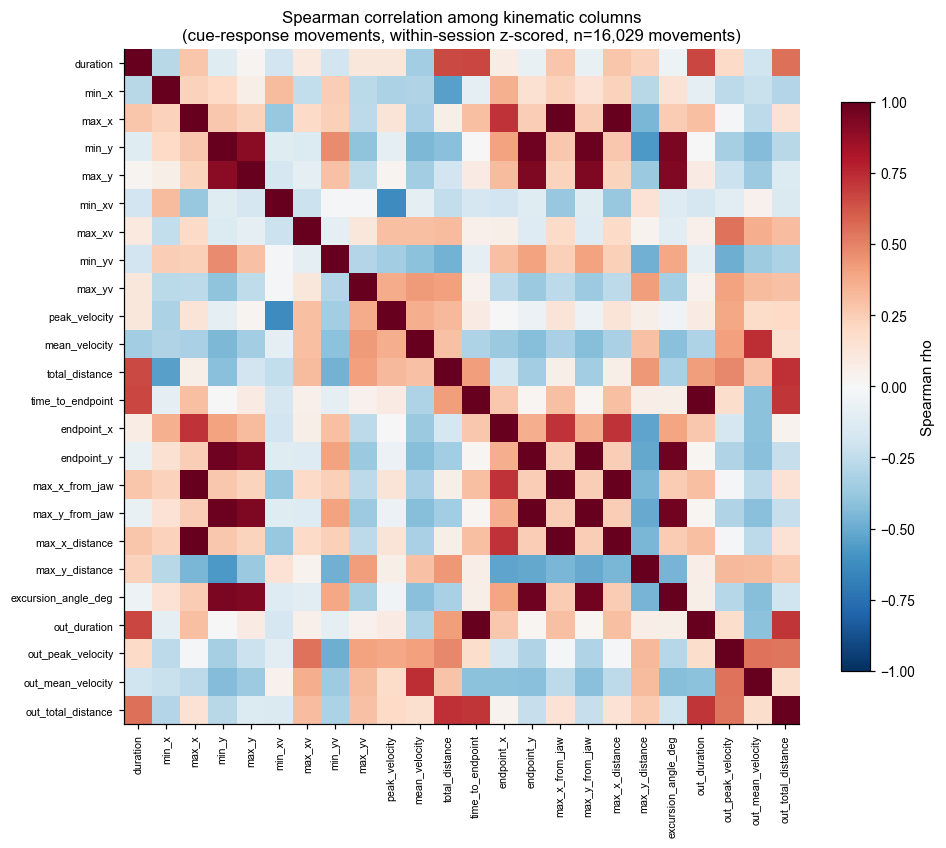

Kinematic pairs with |rho| > 0.7: 21 of 276 pairs (8%)
Median |rho| among all kinematic pairs: 0.27

Column pairs that are effectively identical (|rho| > 0.99):
  max_x                  == max_x_from_jaw         rho = +1.000
  time_to_endpoint       == out_duration           rho = +1.000
  max_x                  == max_x_distance         rho = +1.000
  max_x_from_jaw         == max_x_distance         rho = +1.000
  endpoint_y             == max_y_from_jaw         rho = +0.996


In [16]:
def zscore_within_session(trials, cols, session_col="session"):
    """Z-score the given columns separately within each session.

    Removes each session's own offset and scale, which is what makes pooling
    absolute-pixel columns (``endpoint_x``, ``max_x_from_jaw``, ...) safe: they
    carry a per-session camera/jaw offset that would otherwise dominate any
    pooled statistic.

    Parameters
    ----------
    trials : pandas.DataFrame
        Table with a session column.
    cols : list of str
        Columns to standardise.
    session_col : str
        Grouping column.

    Returns
    -------
    pandas.DataFrame
        Copy with ``cols`` replaced by their within-session z-scores. Columns
        that are constant within a session become NaN there rather than inf.
    """
    out = trials.copy()
    grouped = out.groupby(session_col)[cols]
    means = grouped.transform("mean")
    stds = grouped.transform("std").replace(0.0, np.nan)
    out[cols] = (out[cols] - means) / stds
    return out


# Cue-response movements, within-session z-scored — the same rows section 6 screens,
# but needing no latents, so this runs anywhere.
kin_present = [c for c in KIN_COLS if c in df.columns]
cue_movs = df.loc[df["cue_response"], ["session"] + kin_present]
cue_z = zscore_within_session(cue_movs, kin_present)
kin_corr = cue_z[kin_present].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(kin_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(kin_present)))
ax.set_xticklabels(kin_present, rotation=90, fontsize=7)
ax.set_yticks(range(len(kin_present)))
ax.set_yticklabels(kin_present, fontsize=7)
ax.set_title("Spearman correlation among kinematic columns\n"
             "(cue-response movements, within-session z-scored, n={:,} movements)".format(
                 len(cue_z)))
plt.colorbar(im, ax=ax, shrink=0.75).set_label("Spearman rho")
plt.tight_layout()
save_fig(fig, "kinematic_correlation_structure", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

off_diag = kin_corr.where(~np.eye(len(kin_present), dtype=bool))
strong = (off_diag.abs() > 0.7).sum().sum() / 2
print("Kinematic pairs with |rho| > 0.7: {:.0f} of {:.0f} pairs "
      "({:.0f}%)".format(strong, len(kin_present) * (len(kin_present) - 1) / 2,
                         100 * strong / (len(kin_present) * (len(kin_present) - 1) / 2)))
print("Median |rho| among all kinematic pairs: {:.2f}".format(
    off_diag.abs().stack().median()))

# The sharp version of the caveat: columns that are the SAME variable once each
# session's offset is removed. MI and RF cannot distinguish these even in principle.
duplicates = off_diag.abs().stack()
duplicates = duplicates[duplicates > 0.99]
seen = set()
print("\nColumn pairs that are effectively identical (|rho| > 0.99):")
for (a, b), value in duplicates.sort_values(ascending=False).items():
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    print("  {:<22} == {:<22} rho = {:+.3f}".format(a, b, value))

### 6.2 The screen

Four functions, one per panel, plus an orchestrator. They take their columns as arguments
and hold no notebook state, so the machinery can be exercised on synthetic data
independently of whether the real latents are reachable.

In [17]:
def spearman_screen(trials, kin_cols, model_cols, min_trials=MIN_TRIALS_PER_SESSION,
                    session_col="session", alpha=0.05):
    """Per-session Spearman rho for every kinematic x model pair, tested across sessions.

    The sampling unit is the **session**: rho is computed within each session, and
    the across-session distribution of rho is then tested against zero with a
    Wilcoxon signed-rank test. This is the correction for the pseudo-replication
    the source notebooks carry (see section 3.6).

    Parameters
    ----------
    trials : pandas.DataFrame
        Trial-level table with a session column.
    kin_cols, model_cols : list of str
        Kinematic (feature) and model-latent (target) column names.
    min_trials : int
        Sessions with fewer usable trials are skipped.
    session_col : str
        Grouping column.
    alpha : float
        FDR level passed to ``multipletests``.

    Returns
    -------
    dict
        ``rho_median`` / ``rho_mean`` (DataFrames, kin x model), ``n_sessions``
        (DataFrame of sessions contributing to each cell), ``p`` and ``q``
        (Wilcoxon p-values and their BH-FDR q-values over the whole grid), and
        ``rho_by_session`` (dict of session -> kin x model DataFrame).
    """
    per_session = {}
    for session, grp in trials.groupby(session_col):
        usable = grp[kin_cols + model_cols]
        if usable[model_cols].notna().any(axis=1).sum() < min_trials:
            continue
        corr = usable.corr(method="spearman")
        per_session[session] = corr.loc[kin_cols, model_cols]

    if not per_session:
        empty = pd.DataFrame(np.nan, index=kin_cols, columns=model_cols)
        return {"rho_median": empty, "rho_mean": empty.copy(), "n_sessions": empty.copy(),
                "p": empty.copy(), "q": empty.copy(), "rho_by_session": {}}

    stacked = np.stack([per_session[s].values for s in sorted(per_session)])
    rho_median = pd.DataFrame(np.nanmedian(stacked, axis=0), index=kin_cols, columns=model_cols)
    rho_mean = pd.DataFrame(np.nanmean(stacked, axis=0), index=kin_cols, columns=model_cols)
    n_sessions = pd.DataFrame(np.sum(np.isfinite(stacked), axis=0),
                              index=kin_cols, columns=model_cols)

    pvals = pd.DataFrame(np.nan, index=kin_cols, columns=model_cols)
    for i, kin in enumerate(kin_cols):
        for j, mod in enumerate(model_cols):
            vals = stacked[:, i, j]
            vals = vals[np.isfinite(vals)]
            # Wilcoxon needs at least a handful of sessions and some non-zero spread.
            if len(vals) < 5 or np.allclose(vals, 0):
                continue
            try:
                pvals.iloc[i, j] = stats.wilcoxon(vals).pvalue
            except ValueError:
                continue

    qvals = pd.DataFrame(np.nan, index=kin_cols, columns=model_cols)
    flat = pvals.values.ravel()
    finite = np.isfinite(flat)
    if finite.any():
        corrected = np.full_like(flat, np.nan)
        corrected[finite] = multipletests(flat[finite], alpha=alpha, method="fdr_bh")[1]
        qvals.iloc[:, :] = corrected.reshape(pvals.shape)

    return {"rho_median": rho_median, "rho_mean": rho_mean, "n_sessions": n_sessions,
            "p": pvals, "q": qvals, "rho_by_session": per_session}


def mi_screen(trials_z, kin_cols, model_cols, n_shuffles=5, session_col="session",
              random_state=0):
    """Mutual information between each kinematic and each latent, with a shuffled null.

    Descriptive, with the **trial** as its unit — MI has no analytic null, so the
    reference is a within-session label shuffle, which destroys the kinematics-latent
    pairing while preserving each session's marginal distributions and its
    trial count.

    Parameters
    ----------
    trials_z : pandas.DataFrame
        Within-session z-scored trial table (see :func:`zscore_within_session`).
    kin_cols, model_cols : list of str
        Feature and target column names.
    n_shuffles : int
        Within-session shuffles used to estimate the null. 0 skips the null.
    session_col : str
        Grouping column used for the shuffle.
    random_state : int
        Seed for both ``mutual_info_regression`` and the shuffles.

    Returns
    -------
    dict
        ``mi``, ``mi_null`` and ``mi_corrected`` (= mi - mi_null), each a
        kin x model DataFrame.
    """
    rng = np.random.default_rng(random_state)
    mi = pd.DataFrame(np.nan, index=kin_cols, columns=model_cols)
    mi_null = pd.DataFrame(np.nan, index=kin_cols, columns=model_cols)

    for target in model_cols:
        usable = trials_z[[session_col, target] + kin_cols].dropna()
        if len(usable) < 50:
            continue
        y = usable[target].values
        for feature in kin_cols:
            X = usable[[feature]].values
            mi.loc[feature, target] = mutual_info_regression(
                X, y, random_state=random_state)[0]

        if n_shuffles > 0:
            null = np.zeros((n_shuffles, len(kin_cols)))
            groups = usable[session_col].values
            for k in range(n_shuffles):
                y_shuf = y.copy()
                for session in np.unique(groups):
                    mask = groups == session
                    y_shuf[mask] = rng.permutation(y_shuf[mask])
                for f_i, feature in enumerate(kin_cols):
                    null[k, f_i] = mutual_info_regression(
                        usable[[feature]].values, y_shuf, random_state=random_state)[0]
            mi_null[target] = null.mean(axis=0)

    return {"mi": mi, "mi_null": mi_null, "mi_corrected": mi - mi_null}


def ridge_r2_screen(trials_z, kin_cols, model_cols, session_col="session", n_splits=5,
                    n_shuffles=3, random_state=0):
    """Held-out R2 predicting each latent from all kinematics jointly.

    The only genuinely predictive panel of the four. Cross-validation is
    ``GroupKFold`` on session, so every fold scores sessions the model never saw —
    the same held-out-session discipline ``kin_06`` §8 uses for its lick-side
    decode. The null shuffles the target within session.

    Parameters
    ----------
    trials_z : pandas.DataFrame
        Within-session z-scored trial table.
    kin_cols, model_cols : list of str
        Feature and target column names.
    session_col : str
        Grouping column for ``GroupKFold`` and for the shuffle.
    n_splits : int
        Number of session folds.
    n_shuffles : int
        Shuffled repeats used for the null. 0 skips it.
    random_state : int
        Seed for the shuffles.

    Returns
    -------
    pandas.DataFrame
        Indexed by model column, with ``r2`` (mean across folds), ``r2_std``,
        ``r2_null``, ``r2_null_std`` and ``n_trials``.
    """
    rng = np.random.default_rng(random_state)
    rows = []
    for target in model_cols:
        usable = trials_z[[session_col, target] + kin_cols].dropna()
        groups = usable[session_col].values
        n_groups = len(np.unique(groups))
        if len(usable) < 50 or n_groups < 2:
            rows.append((target, np.nan, np.nan, np.nan, np.nan, len(usable)))
            continue

        splits = min(n_splits, n_groups)
        cv = GroupKFold(n_splits=splits)
        X = usable[kin_cols].values
        y = usable[target].values
        model = RidgeCV(alphas=np.logspace(-3, 3, 13))
        scores = cross_val_score(model, X, y, cv=cv, groups=groups, scoring="r2")

        null_means = []
        for _ in range(n_shuffles):
            y_shuf = y.copy()
            for session in np.unique(groups):
                mask = groups == session
                y_shuf[mask] = rng.permutation(y_shuf[mask])
            null_means.append(cross_val_score(model, X, y_shuf, cv=cv, groups=groups,
                                              scoring="r2").mean())
        rows.append((target, scores.mean(), scores.std(),
                     np.mean(null_means) if null_means else np.nan,
                     np.std(null_means) if null_means else np.nan, len(usable)))

    return pd.DataFrame(rows, columns=["model_col", "r2", "r2_std", "r2_null",
                                       "r2_null_std", "n_trials"]).set_index("model_col")


def rf_importance_screen(trials_z, kin_cols, model_cols, n_estimators=200,
                         random_state=0, min_trials=50):
    """Random-forest Gini importances for each latent, from all kinematics jointly.

    Descriptive only. Importance is split arbitrarily among correlated features
    (see the caveat above section 6.1), so read this as "where the forest looked",
    not as a ranking of which kinematic carries the information.

    Parameters
    ----------
    trials_z : pandas.DataFrame
        Within-session z-scored trial table.
    kin_cols, model_cols : list of str
        Feature and target column names.
    n_estimators : int
        Trees per forest.
    random_state : int
        Seed.
    min_trials : int
        Minimum usable rows before a target is fit.

    Returns
    -------
    pandas.DataFrame
        Importances, kin x model, columns summing to 1 within each fitted target.
    """
    importances = pd.DataFrame(np.nan, index=kin_cols, columns=model_cols)
    for target in model_cols:
        usable = trials_z[[target] + kin_cols].dropna()
        if len(usable) < min_trials:
            continue
        forest = RandomForestRegressor(n_estimators=n_estimators,
                                       random_state=random_state, n_jobs=-1)
        forest.fit(usable[kin_cols].values, usable[target].values)
        importances[target] = forest.feature_importances_
    return importances


def run_value_screen(trials, kin_cols, model_cols, session_col="session",
                     mi_shuffles=5, ridge_shuffles=3, random_state=0):
    """Run all four screens on one trial-level table.

    Parameters
    ----------
    trials : pandas.DataFrame
        Trial-level table with a session column.
    kin_cols, model_cols : list of str
        Feature and target column names.
    session_col : str
        Grouping column.
    mi_shuffles, ridge_shuffles : int
        Null repeats for the MI and ridge panels.
    random_state : int
        Seed.

    Returns
    -------
    dict
        ``spearman`` (dict from :func:`spearman_screen`), ``mi`` (dict from
        :func:`mi_screen`), ``ridge`` (DataFrame), ``rf`` (DataFrame), and
        ``trials_z`` (the standardised table everything but Spearman used).
    """
    present_kin = [c for c in kin_cols if c in trials.columns]
    present_model = [c for c in model_cols if c in trials.columns]
    trials_z = zscore_within_session(trials, present_kin + present_model, session_col)

    return {
        "kin_cols": present_kin,
        "model_cols": present_model,
        "spearman": spearman_screen(trials, present_kin, present_model,
                                    session_col=session_col),
        "mi": mi_screen(trials_z, present_kin, present_model, n_shuffles=mi_shuffles,
                        session_col=session_col, random_state=random_state),
        "ridge": ridge_r2_screen(trials_z, present_kin, present_model,
                                 session_col=session_col, n_shuffles=ridge_shuffles,
                                 random_state=random_state),
        "rf": rf_importance_screen(trials_z, present_kin, present_model,
                                   random_state=random_state),
        "trials_z": trials_z,
    }

In [18]:
def plot_value_screen(results, title, fig_dir=None, save=False, name="value_screen",
                      q_threshold=0.05):
    """Draw the 2x2 summary figure for a screen.

    Ports ``tongue_kinematics`` cell 135's figure, with three changes: the
    Spearman panel shows the **median per-session** rho and marks only cells
    surviving FDR; the MI panel is null-corrected; and the R2 panel shows its
    shuffled null alongside each bar.

    Parameters
    ----------
    results : dict
        Output of :func:`run_value_screen`.
    title : str
        Figure suptitle.
    fig_dir : pathlib.Path, optional
        Passed to ``save_fig``.
    save : bool
        Passed to ``save_fig``.
    name : str
        Base filename.
    q_threshold : float
        FDR level at which a Spearman cell is marked.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    kin_cols = results["kin_cols"]
    model_cols = results["model_cols"]
    rho = results["spearman"]["rho_median"]
    qvals = results["spearman"]["q"]
    mi = results["mi"]["mi_corrected"]
    ridge = results["ridge"]
    rf = results["rf"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 13))

    def _heat(ax, frame, cmap, label, center=False):
        values = frame.reindex(index=kin_cols, columns=model_cols).values.astype(float)
        if center:
            lim = np.nanmax(np.abs(values)) if np.isfinite(values).any() else 1.0
            im = ax.imshow(values, cmap=cmap, vmin=-lim, vmax=lim, aspect="auto")
        else:
            im = ax.imshow(values, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(model_cols)))
        ax.set_xticklabels(model_cols, rotation=90, fontsize=7)
        ax.set_yticks(range(len(kin_cols)))
        ax.set_yticklabels(kin_cols, fontsize=7)
        plt.colorbar(im, ax=ax, shrink=0.8).set_label(label, fontsize=8)
        return im

    # a) Spearman, median across sessions, FDR-significant cells starred.
    _heat(axes[0, 0], rho, "RdBu_r", "median per-session Spearman rho", center=True)
    n_sig = 0
    for i, kin in enumerate(kin_cols):
        for j, mod in enumerate(model_cols):
            q = qvals.loc[kin, mod] if kin in qvals.index and mod in qvals.columns else np.nan
            if np.isfinite(q) and q < q_threshold:
                axes[0, 0].text(j, i, "*", ha="center", va="center", fontsize=9,
                                color="k")
                n_sig += 1
    axes[0, 0].set_title("Spearman: median per-session rho\n"
                         "* = FDR q < {} ({} of {} pairs)".format(
                             q_threshold, n_sig, len(kin_cols) * len(model_cols)),
                         fontsize=10)

    # b) Mutual information, null-corrected.
    _heat(axes[0, 1], mi, "viridis", "MI - within-session shuffled null")
    axes[0, 1].set_title("Mutual information (null-corrected)\n"
                         "descriptive; correlated features report the same value",
                         fontsize=10)

    # c) RidgeCV held-out R2, with its null.
    targets = list(ridge.index)
    x = np.arange(len(targets))
    axes[1, 0].bar(x - 0.2, ridge["r2"].values, width=0.4, color=PALETTE["pos"],
                   yerr=ridge["r2_std"].values, capsize=3, label="Held-out R2")
    axes[1, 0].bar(x + 0.2, ridge["r2_null"].values, width=0.4, color=PALETTE["not_sig"],
                   yerr=ridge["r2_null_std"].values, capsize=3, label="Shuffled null")
    axes[1, 0].axhline(0, color=PALETTE["neutral"], lw=0.8)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(targets, rotation=45, ha="right", fontsize=8)
    axes[1, 0].set_ylabel("R2 (GroupKFold on session)")
    axes[1, 0].set_title("Predicting each latent from ALL kinematics\n"
                         "the only genuinely predictive panel", fontsize=10)
    axes[1, 0].legend(fontsize=8)
    style_ax(axes[1, 0])

    # d) Random-forest importances.
    _heat(axes[1, 1], rf, "magma", "Gini importance")
    axes[1, 1].set_title("Random-forest importances\n"
                         "credit is split arbitrarily among correlated features",
                         fontsize=10)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    save_fig(fig, name, fig_dir=fig_dir, save=save)
    return fig


def summarize_screen(results, q_threshold=0.05, top_n=15):
    """Print the FDR-surviving Spearman pairs and the ridge summary.

    Parameters
    ----------
    results : dict
        Output of :func:`run_value_screen`.
    q_threshold : float
        FDR level.
    top_n : int
        Maximum number of pairs to print.

    Returns
    -------
    pandas.DataFrame
        The surviving pairs, sorted by |median rho| descending.
    """
    rho = results["spearman"]["rho_median"].stack().rename("median_rho")
    qvals = results["spearman"]["q"].stack().rename("q")
    n_sessions = results["spearman"]["n_sessions"].stack().rename("n_sessions")
    table = pd.concat([rho, qvals, n_sessions], axis=1).reset_index()
    table.columns = ["kin_col", "model_col", "median_rho", "q", "n_sessions"]
    survivors = (table[table["q"] < q_threshold]
                 .reindex(table[table["q"] < q_threshold]["median_rho"].abs()
                          .sort_values(ascending=False).index))

    print("Spearman pairs surviving FDR q < {}: {} of {}".format(
        q_threshold, len(survivors), len(table)))
    if len(survivors):
        print(survivors.head(top_n).round(4).to_string(index=False))

    ridge = results["ridge"]
    print("\nHeld-out R2 (GroupKFold on session) vs shuffled null:")
    print(ridge[["r2", "r2_std", "r2_null", "n_trials"]].round(4).to_string())
    beats = ridge[(ridge["r2"] > 0) & (ridge["r2"] > ridge["r2_null"] + 2 * ridge["r2_null_std"])]
    print("\nLatents whose held-out R2 exceeds null + 2 SD: {}".format(
        list(beats.index) if len(beats) else "none"))
    return survivors

In [19]:
if not HAS_TRIALS:
    screen_cue = None
    print("[skip] Systematic screen: Code Ocean only (needs the trial-latent table).")
else:
    screen_cue = run_value_screen(trials_cue, KIN_COLS, MODEL_COLS)
    plot_value_screen(screen_cue,
                      "kin_07 §6 — cue-response movement kinematics vs model latents "
                      "({} sessions, {:,} trials)".format(
                          trials_cue["session"].nunique(), len(trials_cue)),
                      fig_dir=FIG_DIR, save=SAVE_FIG, name="value_screen_cue_response")
    plt.show()
    survivors_cue = summarize_screen(screen_cue)

[skip] Systematic screen: Code Ocean only (needs the trial-latent table).


### 6.3 Do the pinned pairs fall out of the screen?

§5's four pairs were asserted by the source notebooks. If the screen is the honest test,
the pinned pairs should appear in it on their own merits — or not, in which case §5's
regressions were selection artefacts and should be read as such. This cell checks each
pinned pair's position in the full FDR-corrected grid rather than leaving the comparison
to the reader.

`max_x_from_jaw_y_rel` and `max_x_from_jaw_y_distance` are not in `KIN_COLS` (they are
derived in §5 from the jaw keypoint), so the screen is re-run with them appended for this
comparison only.

In [20]:
if not HAS_TRIALS:
    print("[skip] Pinned-pair cross-check: Code Ocean only.")
else:
    extra_kin = ["max_x_from_jaw_y_rel", "max_x_from_jaw_y_distance"]
    screen_pinned = run_value_screen(trials_cue_rel, KIN_COLS + extra_kin, MODEL_COLS,
                                     mi_shuffles=0, ridge_shuffles=0)
    rho = screen_pinned["spearman"]["rho_median"]
    qvals = screen_pinned["spearman"]["q"]

    flat_q = qvals.stack().dropna().sort_values()
    rows = []
    for model_col, kin_col in PINNED_PAIRS:
        if kin_col not in rho.index or model_col not in rho.columns:
            continue
        q = qvals.loc[kin_col, model_col]
        rank = int((flat_q < q).sum()) + 1 if np.isfinite(q) else np.nan
        rows.append((model_col, kin_col, rho.loc[kin_col, model_col], q, rank,
                     "yes" if np.isfinite(q) and q < 0.05 else "no"))
    pinned_in_screen = pd.DataFrame(
        rows, columns=["model_col", "kin_col", "median_rho", "q", "rank_in_grid",
                       "survives_FDR"])

    print("The four pinned pairs, located in the full {}-cell FDR-corrected grid:".format(
        int(np.isfinite(qvals.values).sum())))
    print(pinned_in_screen.round(4).to_string(index=False))
    print("\nIf these pairs rank low and do not survive FDR, §5's regressions are "
          "selection artefacts of the source's search, not findings.")

[skip] Pinned-pair cross-check: Code Ocean only.


## 7. Previous-trial RPE — the LC-relevant question

`tongue_kinematics` cells 137 and 138. Everything above asks whether value modulates the
movement on the **same** trial. This asks something different and, for a noradrenergic
story, more pointed: **does the outcome of the last trial change how the tongue moves on
this one?**

Reward-prediction error is the canonical surprise signal, and LC-NE activity tracks
unexpected outcomes. If RPE on trial *t*−1 predicts kinematics on trial *t*, that is a
behavioural trace of an outcome signal persisting into the next trial's motor output —
the kind of effect a phasic LC response would be expected to leave.

`rpe_prev` is computed on the **complete** trial table and only then merged onto the
trial-level kinematics. That ordering matters: shifting after the merge would make
`rpe_prev` the RPE of the previous *trial that had a cue-response movement*, which can be
several trials back. The sources happen to get this right (they shift `df_trials`); it is
made explicit here because the merge order is easy to invert.

Both trial tables are screened:

- **`trials_cue`** — the cue-response movement only, the direct counterpart to §6.
- **`trials_mean`** — every movement in the trial. This is the table the question really
  wants: "how the animal moves on the next trial" includes the preparatory, non-lick
  movements `kin_05` establishes are real events, not just the choice movement.

`rpe` (current trial) is screened alongside `rpe_prev` as the reference: a kinematic that
correlates with both equally is picking up slow drift, not an outcome effect.

In [21]:
def add_previous_trial_rpe(trial_latents, session_col="session", trial_col="trial"):
    """Add the previous trial's RPE, computed on the complete trial table.

    Parameters
    ----------
    trial_latents : pandas.DataFrame
        Complete per-session trial table (every trial, not only those with a
        cue-response movement) carrying ``rpe``.
    session_col, trial_col : str
        Grouping and ordering columns.

    Returns
    -------
    pandas.DataFrame
        Copy with ``rpe_prev`` added, NaN on each session's first trial.

    Notes
    -----
    Must be applied **before** merging onto movement- or trial-level kinematics.
    Shifting after a merge that drops trials would silently reach further back
    than one trial.
    """
    out = trial_latents.sort_values([session_col, trial_col]).copy()
    out["rpe_prev"] = out.groupby(session_col)["rpe"].shift(1)
    return out


RPE_COLS = ["rpe", "rpe_prev"]

if not HAS_TRIALS:
    screen_rpe_cue = screen_rpe_mean = None
    print("[skip] Previous-trial RPE: Code Ocean only (needs the trial-latent table).")
else:
    trial_latents_rpe = add_previous_trial_rpe(trial_latents)
    rpe_prev_map = trial_latents_rpe[["session", "trial", "rpe_prev"]]

    trials_cue_rpe = trials_cue.merge(rpe_prev_map, on=["session", "trial"], how="left")
    trials_mean_rpe = trials_mean.merge(rpe_prev_map, on=["session", "trial"], how="left")
    print("Trials with a defined rpe_prev: cue {:,} / {:,}, mean {:,} / {:,}".format(
        int(trials_cue_rpe["rpe_prev"].notna().sum()), len(trials_cue_rpe),
        int(trials_mean_rpe["rpe_prev"].notna().sum()), len(trials_mean_rpe)))

    screen_rpe_cue = run_value_screen(trials_cue_rpe, KIN_COLS, RPE_COLS,
                                      mi_shuffles=5, ridge_shuffles=3)
    screen_rpe_mean = run_value_screen(trials_mean_rpe, KIN_COLS, RPE_COLS,
                                       mi_shuffles=5, ridge_shuffles=3)

[skip] Previous-trial RPE: Code Ocean only (needs the trial-latent table).


In [22]:
if not HAS_TRIALS:
    print("[skip] Previous-trial RPE figure: Code Ocean only.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    for row, (label, screen) in enumerate([("cue-response movement", screen_rpe_cue),
                                           ("all movements (trial mean)", screen_rpe_mean)]):
        rho = screen["spearman"]["rho_median"]["rpe_prev"]
        qvals = screen["spearman"]["q"]["rpe_prev"]
        mi = screen["mi"]["mi_corrected"]["rpe_prev"]

        order = rho.abs().sort_values(ascending=False).index
        colors = [PALETTE["sig"] if np.isfinite(qvals[k]) and qvals[k] < 0.05
                  else PALETTE["not_sig"] for k in order]
        axes[row, 0].barh(range(len(order)), rho[order].values, color=colors,
                          edgecolor="k", lw=0.4)
        axes[row, 0].set_yticks(range(len(order)))
        axes[row, 0].set_yticklabels(order, fontsize=7)
        axes[row, 0].invert_yaxis()
        axes[row, 0].axvline(0, color=PALETTE["neutral"], lw=0.8)
        axes[row, 0].set_xlabel("median per-session Spearman rho vs rpe_prev")
        axes[row, 0].set_title("Spearman with previous-trial RPE — {}\n"
                               "orange = FDR q < 0.05".format(label), fontsize=10)
        style_ax(axes[row, 0])

        mi_order = mi.sort_values(ascending=False).index
        axes[row, 1].barh(range(len(mi_order)), mi[mi_order].values,
                          color=PALETTE["baseline"], edgecolor="k", lw=0.4)
        axes[row, 1].set_yticks(range(len(mi_order)))
        axes[row, 1].set_yticklabels(mi_order, fontsize=7)
        axes[row, 1].invert_yaxis()
        axes[row, 1].axvline(0, color=PALETTE["neutral"], lw=0.8)
        axes[row, 1].set_xlabel("MI - within-session shuffled null")
        axes[row, 1].set_title("Mutual information with rpe_prev — {}".format(label),
                               fontsize=10)
        style_ax(axes[row, 1])

    plt.tight_layout()
    save_fig(fig, "previous_trial_rpe_screen", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    for label, screen in [("cue-response movement", screen_rpe_cue),
                          ("trial mean", screen_rpe_mean)]:
        print("\n=== rpe / rpe_prev screen — {} ===".format(label))
        summarize_screen(screen)

[skip] Previous-trial RPE figure: Code Ocean only.


In [23]:
if not HAS_TRIALS:
    print("[skip] RPE(n) vs RPE(n+1) comparison: Code Ocean only.")
else:
    # tongue_kinematics cell 138: is a kinematic's relationship to the PREVIOUS trial's
    # RPE distinguishable from its relationship to the CURRENT trial's? Points on the
    # unity line are consistent with slow drift shared by both, not a carry-over effect.
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    for ax, (label, screen) in zip(axes, [("cue-response movement", screen_rpe_cue),
                                          ("all movements (trial mean)", screen_rpe_mean)]):
        rho = screen["spearman"]["rho_median"]
        qvals = screen["spearman"]["q"]
        x = rho["rpe_prev"]
        y = rho["rpe"]
        sig = [(np.isfinite(qvals.loc[k, "rpe_prev"]) and qvals.loc[k, "rpe_prev"] < 0.05)
               for k in rho.index]
        ax.scatter(x[~np.array(sig)], y[~np.array(sig)], s=40,
                   color=PALETTE["not_sig"], edgecolors="k", lw=0.4, label="n.s.")
        ax.scatter(x[np.array(sig)], y[np.array(sig)], s=55, color=PALETTE["sig"],
                   edgecolors="k", lw=0.4, label="rpe_prev FDR q < 0.05")
        for kin in rho.index:
            if np.isfinite(x[kin]) and np.isfinite(y[kin]):
                ax.annotate(kin, (x[kin], y[kin]), fontsize=6,
                            xytext=(3, 3), textcoords="offset points")

        lims = [np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])]
        ax.plot(lims, lims, ls="--", color=PALETTE["accent"], lw=1, label="unity")
        ax.axhline(0, color=PALETTE["neutral"], lw=0.6)
        ax.axvline(0, color=PALETTE["neutral"], lw=0.6)
        ax.set(xlabel="median rho vs RPE(n-1)", ylabel="median rho vs RPE(n)",
               title=label)
        ax.legend(fontsize=8)
        style_ax(ax)

    plt.suptitle("Previous- vs current-trial RPE correlations with kinematics", fontsize=11)
    plt.tight_layout()
    save_fig(fig, "rpe_prev_vs_current", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

[skip] RPE(n) vs RPE(n+1) comparison: Code Ocean only.


## 8. What this notebook does and does not establish

**Status: written, not executed.** The model-latent fetch resolves and was exercised
across all 44 sessions while this notebook was written (40 resolve for
`QLearning_L2F1_CKfull_softmax`; the four sessions of subject 751004 have no MLE records),
but everything from §3.4 onward additionally needs per-session `nwb_df_trials.parquet`,
which exists only on Code Ocean. §6.1 is the one section that has actually run. The
screen machinery in §6.2 was verified separately against a synthetic latent built as a
known function of one kinematic column (`excursion_angle_deg`, which has ρ = 0.97 twins in
the data, so this was a discrimination test rather than a free one). All four methods
ranked the planted driver first, at both a strong and a weak noise level; the pure-noise
control latent returned q = 0.99 for the driver and held-out R² = −0.001, and the RidgeCV
panel ordered strong > weak > noise. The wiring is checked even though the real data path
is not.

**What to look at first when this runs on Code Ocean, in order:**

1. **§3.5's L/R convention check.** If it prints CONTRADICTED, stop — every sign below is
   inverted and nothing else is worth reading.
2. **§3.4's `latent_index_mode` tally.** It should be "responded" for every session. A
   mixture means the upstream fit's trial indexing is not uniform, and the merge in §3.6
   is misaligned for whichever sessions differ.
3. **§6's RidgeCV R² bars.** This is the result. If held-out R² sits at or below its
   shuffled null for every latent, the answer to the notebook's title question is **no**
   at this level of analysis, regardless of how many Spearman cells survive FDR — a
   consistent but tiny within-session rank correlation is not encoding.
4. **§6.3.** Whether §5's four pinned pairs survive the full grid. If they do not, that is
   worth recording: it means the source notebooks' headline value-kinematics relationships
   were selection artefacts.
5. **§7.** Whether `rpe_prev` separates from `rpe` at all. Points sitting on the unity line
   in the final figure mean both are tracking slow session drift, not a carry-over.

**Known limitations, none of them fixed here:**

- `excursion_angle_deg` is a circular quantity treated linearly throughout, as the sources
  do. For movements confined to one hemifield this is benign; near the wrap point it is
  not.
- The screen conditions on nothing. Value covaries with block structure, with choice side,
  and with time in session — `kin_06` §8.4 shows how strong the choice-side/previous-choice
  confound is in this dataset. A Spearman ρ between `q_diff` and a kinematic that differs
  by lick side will be non-zero for that reason alone. A partial-correlation or
  within-choice-stratum version of §6 is the obvious next step and is **not** done here.
- One agent (`QLearning_L2F1_CKfull_softmax`), taken from the sources without a model-
  comparison step. `model_quality.ipynb` is where that question lives.
- Sessions are treated as exchangeable in the across-session tests, but they come from 13
  subjects with 1–4 sessions each. A subject-level random effect would be more correct;
  the Wilcoxon across sessions is the simpler, mildly anti-conservative choice.